In [263]:
import tensorflow as tf

In [264]:
histos={}
nb_epochs = 30

In [265]:
data = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = data.load_data()

In [266]:
training_images.shape, training_images

((60000, 28, 28),
 array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0,

In [267]:
training_images.ndim

3

In [268]:
test_images.shape

(10000, 28, 28)

In [269]:
training_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [270]:
training_labels.shape

(60000,)

In [271]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [272]:
labels = ["t-shirt/top", "trouser", "pullover", "dress", "coat", "sandals", "shirt",
         "sneaker", "bag", "ankle boot"]
labels = ["t-shirt/haut", "pantalon", "pull", "robe", "manteau", "sandales", "chemise",
"baskets", "sac", "bottines"]

In [273]:
labels[8]

'sac'

In [274]:
training_images[45]

array([[  0,   0,   0,   1,   0,   0,   0,   0,   0,  34, 148, 202, 107,
         84, 162, 198,  90,  26,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  21, 107, 166, 168, 152, 204, 238,
        248, 237, 190, 142, 178, 158,  98,  17,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  55, 188, 140, 131, 121, 119, 116, 146,
        157, 132, 115, 136, 125, 140, 143, 181,  51,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 167, 134, 113, 130, 134, 140, 132, 125,
        125, 131, 135, 130, 133, 131, 115, 135, 163,   6,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  58, 148, 133, 124, 134, 128, 135, 128, 133,
        130, 133, 137, 138, 130, 124, 130, 133, 147,  82,   0,   1,   0,
          0,   0],
       [  0,   0,   0,   0,  86, 148, 158, 139, 124, 120, 131, 134, 132,
        134, 124, 134, 132, 137, 126, 137, 136, 146, 114,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 112, 141, 174, 143, 117, 134, 130, 128, 131,
        136, 134, 128, 128, 131, 106, 187, 149, 147, 143,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 134, 151, 167, 154, 114, 134, 138, 139, 135,
        135, 130, 130, 124, 129, 119, 229, 141, 145, 164,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 154, 169, 157, 109, 147, 140, 137, 137,
        136, 142, 141, 139, 129, 123, 201, 146, 138, 172,  21,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 145, 158, 171, 175, 111, 136, 145, 136, 135,
        138, 137, 143, 146, 140, 122, 184, 167, 136, 170,  58,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 151, 155, 189, 183, 120, 135, 132, 136, 135,
        133, 128, 130, 134, 120, 153, 230, 156, 135, 167,  83,   0,   0,
          0,   0],
       [  0,   0,   0,   1, 166, 151, 208, 175, 116, 142, 144, 138, 149,
        133, 131, 137, 140, 119, 126, 206, 198, 141, 166, 101,   0,   0,
          0,   0],
       [  0,   0,   0,   6, 169, 146, 237, 187, 104, 131, 136, 149, 147,
        137, 137, 137, 132, 137, 113, 166, 206, 151, 162, 126,   0,   0,
          0,   0],
       [  0,   0,   0,  20, 180, 136, 231, 214, 105, 134, 140, 139, 136,
        137, 136, 148, 134, 149, 111, 139, 255, 151, 158, 147,   0,   0,
          0,   0],
       [  0,   0,   0,  33, 184, 109, 217, 182, 105, 124, 143, 131, 135,
        137, 139, 138, 131, 142, 132,  99, 249, 162, 157, 172,   0,   0,
          0,   0],
       [  0,   0,   0,  35, 180, 112, 233, 143, 109, 133, 145, 146, 142,
        142, 139, 141, 135, 141, 152, 101, 205, 163, 154, 170,   0,   0,
          0,   0],
       [  0,   0,   0,  42, 183, 123, 217, 117, 126, 137, 140, 134, 137,
        135, 143, 141, 133, 133, 149, 107, 166, 176, 153, 169,  14,   0,
          0,   0],
       [  0,   0,   0,  48, 175, 147, 210, 101, 119, 136, 142, 137, 142,
        139, 147, 142, 146, 126, 138, 102, 131, 197, 161, 183,  32,   0,
          0,   0],
       [  0,   0,   0,  56, 165, 163, 213,  74, 126, 138, 149, 133, 133,
        132, 141, 134, 142, 132, 132, 126, 117, 193, 162, 172,  39,   0,
          0,   0],
       [  0,   0,   0,  62, 157, 165, 227,  39, 135, 138, 136, 142, 146,
        143, 136, 138, 134, 141, 134, 116,  78, 197, 171, 156,  44,   0,
          0,   0],
       [  0,   0,   0,  65, 162, 169, 245,  39, 140, 133, 133, 128, 132,
        134, 143, 145, 134, 133, 134, 128,  36, 208, 172, 151,  55,   0,
          0,   0],
       [  0,   0,   0,  72, 147, 168, 244,  25, 142, 137, 138, 133, 128,
        132, 147, 145, 135, 136, 133, 131,  26, 207, 173, 149,  67,   0,
          0,   0],
       [  0,   0,   0,  68, 153, 179, 250,  11, 135, 134, 139, 133, 136,
        140, 140, 143, 145, 140, 131, 126,  32, 207, 175, 136,  73,   0,
          0,   0],
       [  0,   0,   0,  61, 155, 180, 252,  23, 151, 132, 131, 133, 133,
        129, 135, 140, 132, 139, 132, 139,  38, 221, 174, 135,  77,   0,
          0,   0],
       [  0,   0,   0,  18, 147, 187, 18

In [275]:
training_images.min(), training_images.max()

(np.uint8(0), np.uint8(255))

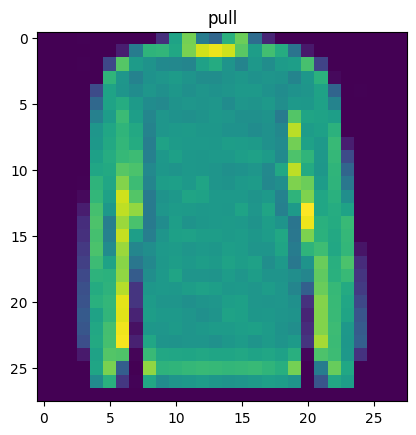

In [276]:
import matplotlib.pyplot as plt
plt.imshow(training_images[45])
plt.title(labels[training_labels[45]])
plt.show()

In [277]:
training_labels[45]

np.uint8(2)

In [278]:
labels[2]

'pull'

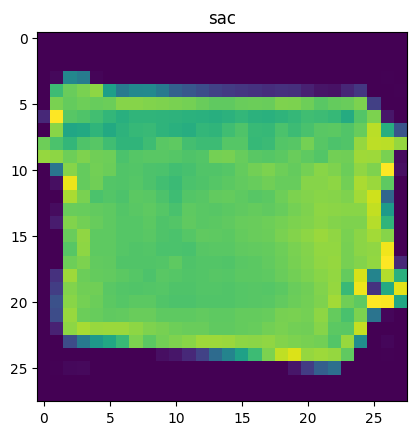

In [279]:
import matplotlib.pyplot as plt
plt.imshow(training_images[12345])
plt.title(labels[training_labels[12345]])
plt.show()

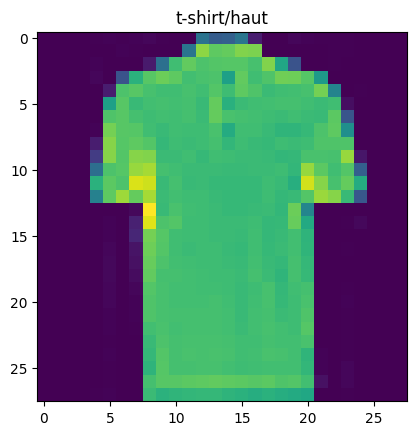

In [280]:
import matplotlib.pyplot as plt
plt.imshow(training_images[48978])
plt.title(labels[training_labels[48978]])
plt.show()

# Flatten (Applatir l'images)

In [281]:
training_images.shape

(60000, 28, 28)

In [282]:
a_training_images = training_images.reshape((60000, 28*28))
a_test_images = test_images.reshape(-1, 28*28) # -1 = toutes les images du dataset

In [283]:
a_training_images.shape, a_test_images.shape

((60000, 784), (10000, 784))

# One hot encoding

In [284]:
import numpy as np
x = np.array([1, 2, 1, 0, 3])

In [285]:
tf.keras.utils.to_categorical(x)

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.]])

In [286]:
training_labels.shape

(60000,)

In [287]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [288]:
training_labels.shape

(60000, 10)

In [289]:
training_labels[45]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

# Softmax

In [290]:
output = [6, 3, 2]

In [291]:
6/(6+3+2) + 3/(6+3+2) + 2/(6+3+2)

1.0

In [292]:
3/(6+3+2)

0.2727272727272727

In [293]:
6/(6+3+2)

0.5454545454545454

In [294]:
2/(6+3+2)

0.18181818181818182

In [295]:
import numpy as np

In [296]:
def softmax(vect):
  r = np.exp(np.array(vect))
  return r/sum(r)

In [297]:
softmax([6, 3, 2])

array([0.93623955, 0.04661262, 0.01714783])

In [298]:
[1, 0, 0]

[1, 0, 0]

# 1er modèle de classification

In [299]:
## Normalisation des données

In [300]:
a_training_images.min(), a_training_images.max()

(np.uint8(0), np.uint8(255))

In [301]:
a_training_images = a_training_images /255.0
a_test_images = a_test_images / 255.0

In [302]:
a_training_images.min(), a_training_images.max()

(np.float64(0.0), np.float64(1.0))

In [303]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [304]:
model = Sequential([ Dense(units=784, activation="sigmoid"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="mse", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
# model.compile(loss="mse", optimizer=SGD(learning_rate=0.01))
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.1419 - loss: 0.0902 - val_accuracy: 0.3481 - val_loss: 0.0869
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3957 - loss: 0.0859 - val_accuracy: 0.4212 - val_loss: 0.0828
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4198 - loss: 0.0815 - val_accuracy: 0.4417 - val_loss: 0.0781
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4507 - loss: 0.0767 - val_accuracy: 0.4887 - val_loss: 0.0731
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5141 - loss: 0.0720 - val_accuracy: 0.5534 - val_loss: 0.0684
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5674 - loss: 0.0673 - val_accuracy: 0.6074 - val_loss: 0.0642
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6194 - loss: 0.0630 - val_accuracy: 0.6591 - val_loss: 0.0604
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6615 - loss: 0.0594 

In [305]:
histos['MSE']=h

In [306]:
type(h)
summary = {
    k: [float(x) if x != "..." else "..." for x in (v[:3] + ["..."] + v[-3:])]
    for k, v in h.history.items()
}
"3 premières et 3 dernières valeurs :", dict(summary)

('3 premières et 3 dernières valeurs :',
 {'accuracy': [0.21281667053699493,
   0.4090000092983246,
   0.4245166778564453,
   '...',
   0.7569666504859924,
   0.7601000070571899,
   0.7613666653633118],
  'loss': [0.08890271186828613,
   0.08489023149013519,
   0.0804082378745079,
   '...',
   0.036060232669115067,
   0.03571031242609024,
   0.03538183122873306],
  'val_accuracy': [0.3481000065803528,
   0.4212000072002411,
   0.4417000114917755,
   '...',
   0.7533000111579895,
   0.7555000185966492,
   0.7566999793052673],
  'val_loss': [0.08693784475326538,
   0.08280596137046814,
   0.07805681973695755,
   '...',
   0.03653040900826454,
   0.036209940910339355,
   0.035907723009586334]})

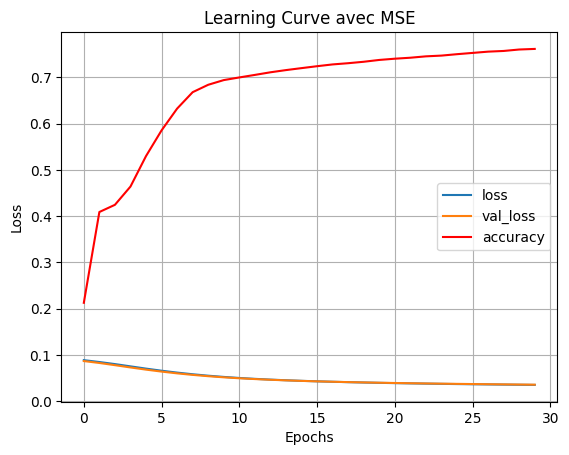

In [307]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec MSE")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

In [308]:
# accuracy: 0.5480 - loss: 0.0717 - val_accuracy: 0.5903 - val_loss: 0.0682

In [309]:
3/5

0.6

# MSE VS Cross-entropy ou Log loss

In [310]:
def mse(target, prediction):
  loss = (prediction-target) ** 2
  return loss

In [311]:
def log_loss(target, prediction):
  loss = - 1* np.log(prediction)
  return loss

In [312]:
prediction = np.arange(0, 1, 0.01)
prediction

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

In [313]:
target = np.ones_like(prediction)
target

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [314]:
loss_mse = mse(target, prediction)
loss_ce = log_loss(target, prediction)

/tmp/ipython-input-4183768036.py:2: RuntimeWarning: divide by zero encountered in log
  loss = - 1* np.log(prediction)


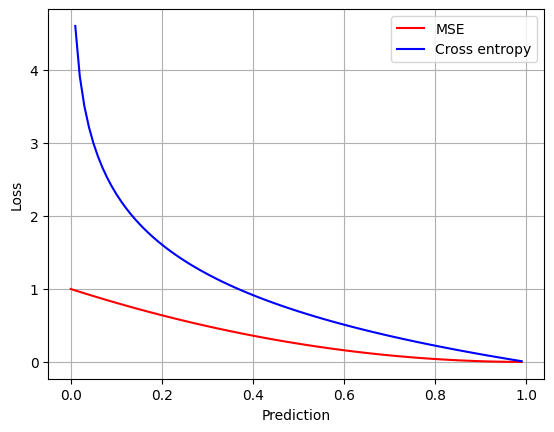

In [315]:
plt.plot(prediction, loss_mse, c='r', label='MSE')
plt.plot(prediction, loss_ce, c='b', label="Cross entropy")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [316]:
def log_loss(target, prediction):
  loss = - 1* np.log(1-prediction)
  return loss

In [317]:
np.zeros_like

<function zeros_like at 0x7c7c6d32a9f0>

In [318]:
target = np.zeros_like(prediction)
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [319]:
loss_mse = mse(target, prediction)
loss_ce = log_loss(target, prediction)

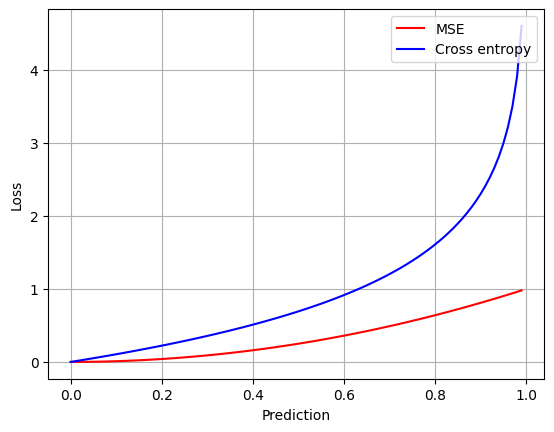

In [320]:
plt.plot(prediction, loss_mse, c='red', label='MSE')
plt.plot(prediction, loss_ce, c='blue', label="Cross entropy")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

# Entrainement avec cross entropy comme Loss

In [321]:
model = Sequential([ Dense(units=784, activation="sigmoid"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5602 - loss: 1.4992 - val_accuracy: 0.7389 - val_loss: 0.7851
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7543 - loss: 0.7376 - val_accuracy: 0.7629 - val_loss: 0.6676
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7795 - loss: 0.6341 - val_accuracy: 0.7801 - val_loss: 0.6164
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7981 - loss: 0.5801 - val_accuracy: 0.7925 - val_loss: 0.5780
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8088 - loss: 0.5529 - val_accuracy: 0.8035 - val_loss: 0.5532
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8154 - loss: 0.5353 - val_accuracy: 0.8097 - val_loss: 0.5359
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8203 - loss: 0.5155 - val_accuracy: 0.8150 - val_loss: 0.5228
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8272 - loss: 0.494

In [322]:
histos['CROSS ENTROPY']=h

# Epoch 5/5
# MSE           : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520

# Epoch 50/50
# MSE           : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202

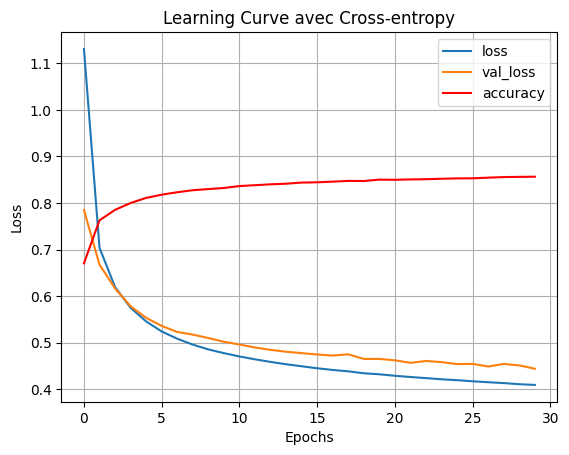

In [323]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec Cross-entropy")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

# Nouvelle fonction d'activation : Relu (REctified Linear Unit)

In [324]:
values = np.arange(-5, 5, 0.01)

In [325]:
sig = tf.nn.sigmoid(values)

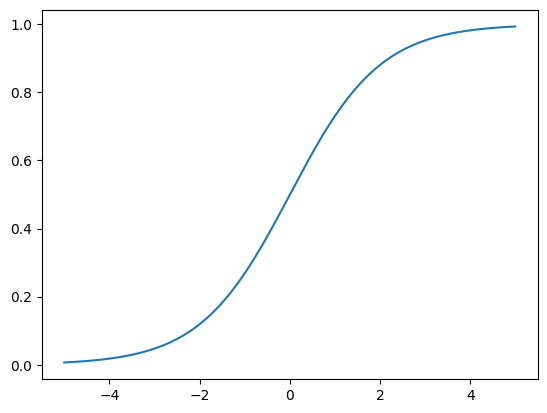

In [326]:
plt.plot(values, sig)
plt.show()

In [327]:
def relu(vect):
  return np.maximum(0, vect)

In [328]:
relu_values = relu(values)

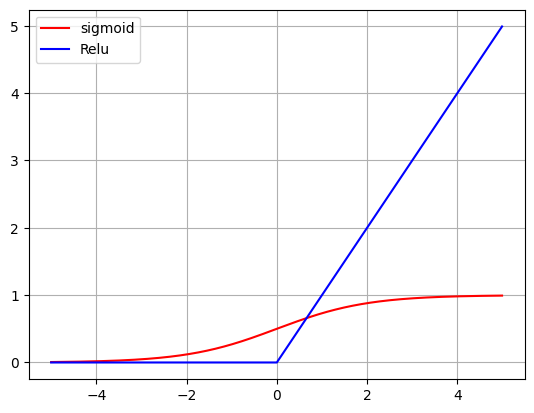

In [329]:
plt.plot(values, sig, c='r', label="sigmoid")
plt.plot(values, relu_values, c='b', label="Relu")
plt.legend(loc="upper left")
plt.grid()
plt.show()

In [330]:
model = Sequential([ Dense(units=784, activation="relu"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7131 - loss: 0.9246 - val_accuracy: 0.8116 - val_loss: 0.5475
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8312 - loss: 0.5076 - val_accuracy: 0.8219 - val_loss: 0.5117
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8430 - loss: 0.4600 - val_accuracy: 0.8350 - val_loss: 0.4781
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8515 - loss: 0.4290 - val_accuracy: 0.8388 - val_loss: 0.4522
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8593 - loss: 0.4162 - val_accuracy: 0.8413 - val_loss: 0.4537
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8639 - loss: 0.3971 - val_accuracy: 0.8475 - val_loss: 0.4299
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8671 - loss: 0.3850 - val_accuracy: 0.8552 - val_loss: 0.4103
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8708 - loss: 0.3681 

In [331]:
histos['relu']=h
# Epoch 5/5
# MSE           : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520
# relu          : accuracy: 0.8570 - loss: 0.4169 - val_accuracy: 0.8406 - val_loss: 0.4453

# Epoch 50/50
# MSE           : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202
# relu          : accuracy: 0.9247 - loss: 0.2136 - val_accuracy: 0.8892 - val_loss: 0.3137

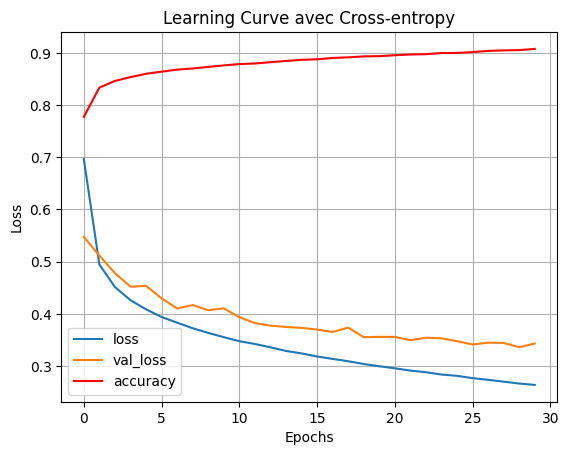

In [332]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec Cross-entropy")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

# Réseau de neurones plus complexe

In [333]:
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (32, 10)               │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,292 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [334]:
model = Sequential([ Dense(units=784, activation="relu"),
                     Dense(units=128, activation="relu"),
                     Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7120 - loss: 0.9190 - val_accuracy: 0.8172 - val_loss: 0.5330
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8334 - loss: 0.4804 - val_accuracy: 0.8423 - val_loss: 0.4551
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8530 - loss: 0.4206 - val_accuracy: 0.8426 - val_loss: 0.4420
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8602 - loss: 0.3999 - val_accuracy: 0.8421 - val_loss: 0.4324
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8701 - loss: 0.3761 - val_accuracy: 0.8552 - val_loss: 0.4017
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8705 - loss: 0.3665 - val_accuracy: 0.8616 - val_loss: 0.3896
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8783 - loss: 0.3461 - val_accuracy: 0.8562 - val_loss: 0.3918
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8814 - loss: 0.

In [335]:
histos['complexe']=h
# Epoch 5/5
# MSE            : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY  : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520
# relu           : accuracy: 0.8570 - loss: 0.4169 - val_accuracy: 0.8406 - val_loss: 0.4453
# model complexe : accuracy: 0.8676 - loss: 0.3768 - val_accuracy: 0.8541 - val_loss: 0.4082

# Epoch 50/50
# MSE            : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY  : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202
# relu           : accuracy: 0.9247 - loss: 0.2136 - val_accuracy: 0.8892 - val_loss: 0.3137
# model complexe :

In [336]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [337]:
import matplotlib.pyplot as plt


def plot_loss_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label = "loss")
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label="val_loss")
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Loss Curve")
  plt.legend(loc='upper right')
  plt.show()


def plot_accuracy_curve(history):

  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label = "accuracy")
  plt.plot(list(range(len(history['val_accuracy']))), history['val_accuracy'], label="val_accuracy")
  plt.xlabel('Epochs')
  plt.ylabel("accuracy")
  plt.title("Accuracy Curve")
  plt.legend(loc='upper left')
  plt.show()


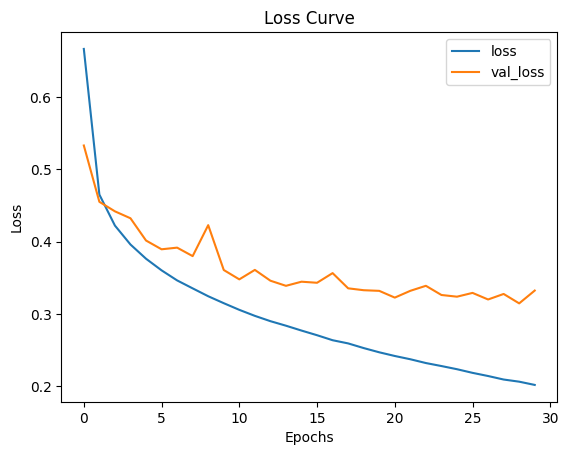

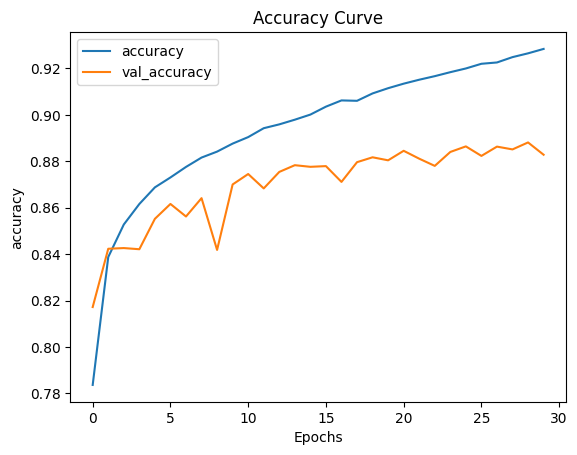

In [338]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

# Combattre le overfitting : Dropout

In [339]:
dropout = tf.keras.layers.Dropout(0.5, input_shape=(2,))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [340]:
# ?tf.keras.layers.Dropout

In [341]:
x = np.arange(1,11).reshape(5, 2).astype(np.float32)

In [342]:
x

array([[ 1.,  2.],
       [ 3.,  4.],
       [ 5.,  6.],
       [ 7.,  8.],
       [ 9., 10.]], dtype=float32)

In [343]:
dropout(x, training=True)

<tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 0.,  4.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [18.,  0.]], dtype=float32)>

In [344]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))
# default: epochs=50

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.6069 - loss: 1.1340 - val_accuracy: 0.8071 - val_loss: 0.5499
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7946 - loss: 0.5940 - val_accuracy: 0.8286 - val_loss: 0.4832
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8196 - loss: 0.5196 - val_accuracy: 0.8422 - val_loss: 0.4441
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8303 - loss: 0.4800 - val_accuracy: 0.8436 - val_loss: 0.4357
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8417 - loss: 0.4473 - val_accuracy: 0.8526 - val_loss: 0.4109
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8477 - loss: 0.4305 - val_accuracy: 0.8562 - val_loss: 0.4003
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8506 - loss: 0.4178 - val_accuracy: 0.8574 - val_loss: 0.3967
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8549 - loss: 0

In [345]:
histos['Dropout']=h

# Cf bilan en fin de doc

In [346]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

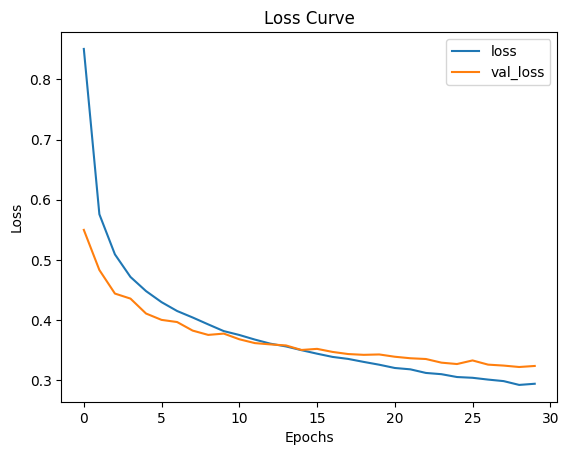

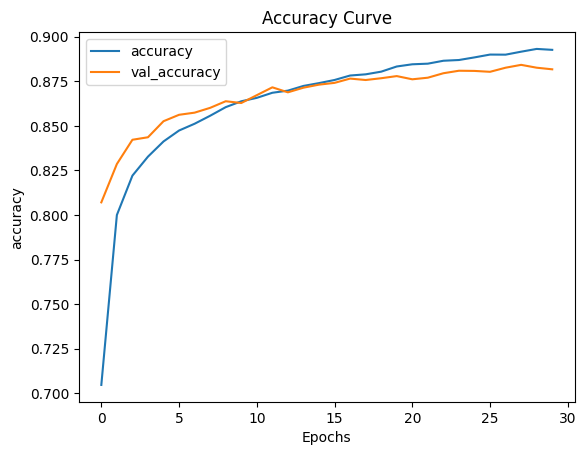

In [347]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

# Adam optimiser (Momentum)

In [348]:
adam = tf.keras.optimizers.Adam(
    learning_rate=0.01,
    beta_1=0.9,
    beta_2=0.999)

In [349]:
model = Sequential([
    Dense(units=784, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    Dense(units=128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    Dense(units=10, activation="softmax"),
])
model.compile(loss="categorical_crossentropy", optimizer=adam, metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6185 - loss: 1.1398 - val_accuracy: 0.7733 - val_loss: 0.6138
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6728 - loss: 0.9130 - val_accuracy: 0.7823 - val_loss: 0.5915
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.6781 - loss: 0.9042 - val_accuracy: 0.7773 - val_loss: 0.6627
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.6834 - loss: 0.8930 - val_accuracy: 0.7715 - val_loss: 0.6470
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6856 - loss: 0.8791 - val_accuracy: 0.7190 - val_loss: 0.7229
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.6778 - loss: 0.9091 - val_accuracy: 0.7952 - val_loss: 0.6127
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6858 - loss: 0.8757 - val_accuracy: 0.7777 - val_loss: 0.6088
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6912 - loss

In [350]:
histos['Adam'] = h

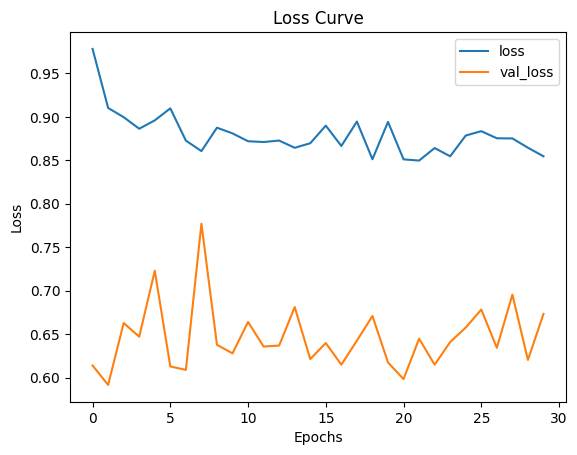

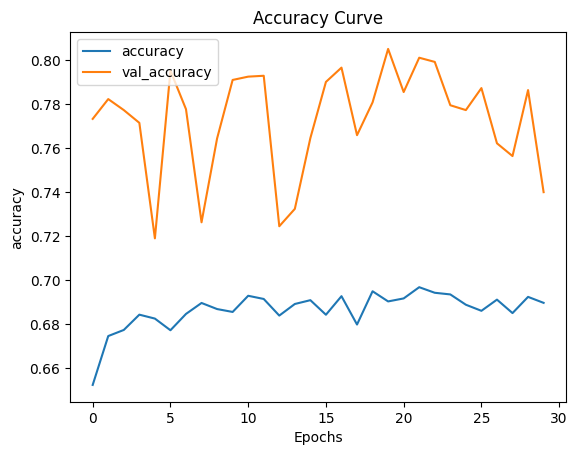

In [351]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

In [352]:
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,151,632 (8.21 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,434,422 (5.47 MB)

# Model Checkpoint

In [353]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [354]:
best_model = "best_model.h5"

model_ckp = ModelCheckpoint(
    filepath=best_model,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

In [355]:
model = Sequential([
    Dense(units=784, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    Dense(units=128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    Dense(units=10, activation="softmax"),
])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels,
              epochs=nb_epochs,
              validation_data=(a_test_images, test_labels),
              callbacks =[model_ckp])
# default: epochs=50

Epoch 1/30
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6037 - loss: 1.1321

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6039 - loss: 1.1314 - val_accuracy: 0.8003 - val_loss: 0.5638
Epoch 2/30
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7907 - loss: 0.6009

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7907 - loss: 0.6008 - val_accuracy: 0.8222 - val_loss: 0.4914
Epoch 3/30
1865/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8160 - loss: 0.5299

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8160 - loss: 0.5298 - val_accuracy: 0.8373 - val_loss: 0.4577
Epoch 4/30
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8280 - loss: 0.4861

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8280 - loss: 0.4860 - val_accuracy: 0.8417 - val_loss: 0.4361
Epoch 5/30
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8387 - loss: 0.4564

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8387 - loss: 0.4564 - val_accuracy: 0.8494 - val_loss: 0.4171
Epoch 6/30
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8440 - loss: 0.4354

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8440 - loss: 0.4354 - val_accuracy: 0.8537 - val_loss: 0.4059
Epoch 7/30
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8508 - loss: 0.4153

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8508 - loss: 0.4153 - val_accuracy: 0.8582 - val_loss: 0.3937
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8509 - loss: 0.4104

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8509 - loss: 0.4104 - val_accuracy: 0.8602 - val_loss: 0.3889
Epoch 9/30
1867/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8609 - loss: 0.3938

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8609 - loss: 0.3938 - val_accuracy: 0.8607 - val_loss: 0.3861
Epoch 10/30
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8623 - loss: 0.3816

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8623 - loss: 0.3816 - val_accuracy: 0.8625 - val_loss: 0.3811
Epoch 11/30
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8647 - loss: 0.3819

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8647 - loss: 0.3819 - val_accuracy: 0.8653 - val_loss: 0.3708
Epoch 12/30
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8660 - loss: 0.3751

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8660 - loss: 0.3751 - val_accuracy: 0.8688 - val_loss: 0.3690
Epoch 13/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8710 - loss: 0.3622 - val_accuracy: 0.8687 - val_loss: 0.3629
Epoch 14/30
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8712 - loss: 0.3540

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8712 - loss: 0.3540 - val_accuracy: 0.8711 - val_loss: 0.3576
Epoch 15/30
1868/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8706 - loss: 0.3557

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8706 - loss: 0.3557 - val_accuracy: 0.8736 - val_loss: 0.3529
Epoch 16/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8748 - loss: 0.3461 - val_accuracy: 0.8722 - val_loss: 0.3544
Epoch 17/30
1868/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8767 - loss: 0.3415

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8767 - loss: 0.3415 - val_accuracy: 0.8754 - val_loss: 0.3487
Epoch 18/30
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8764 - loss: 0.3398

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8764 - loss: 0.3398 - val_accuracy: 0.8773 - val_loss: 0.3429
Epoch 19/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8819 - loss: 0.3282 - val_accuracy: 0.8742 - val_loss: 0.3465
Epoch 20/30
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8821 - loss: 0.3248

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8821 - loss: 0.3248 - val_accuracy: 0.8779 - val_loss: 0.3389
Epoch 21/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8843 - loss: 0.3226 - val_accuracy: 0.8767 - val_loss: 0.3415
Epoch 22/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8843 - loss: 0.3204 - val_accuracy: 0.8774 - val_loss: 0.3384
Epoch 23/30
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8849 - loss: 0.3120

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8849 - loss: 0.3120 - val_accuracy: 0.8804 - val_loss: 0.3333
Epoch 24/30
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8859 - loss: 0.3104

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8859 - loss: 0.3104 - val_accuracy: 0.8820 - val_loss: 0.3312
Epoch 25/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8858 - loss: 0.3126 - val_accuracy: 0.8803 - val_loss: 0.3341
Epoch 26/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8872 - loss: 0.3060 - val_accuracy: 0.8790 - val_loss: 0.3303
Epoch 27/30
1864/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8920 - loss: 0.3037

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8920 - loss: 0.3037 - val_accuracy: 0.8832 - val_loss: 0.3295
Epoch 28/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8922 - loss: 0.2971 - val_accuracy: 0.8814 - val_loss: 0.3257
Epoch 29/30
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8934 - loss: 0.2940

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8934 - loss: 0.2940 - val_accuracy: 0.8833 - val_loss: 0.3262
Epoch 30/30
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8936 - loss: 0.2910

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8936 - loss: 0.2910 - val_accuracy: 0.8839 - val_loss: 0.3287


In [356]:
model_save = tf.keras.models.load_model('best_model.h5')

In [357]:
model_save.evaluate(a_test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8859 - loss: 0.3280


[0.32869425415992737, 0.883899986743927]

# Early Stopping

In [358]:
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7)

In [359]:
model_ckp

In [360]:
model = Sequential([ Dense(units=784, activation="relu"),
                     tf.keras.layers.Dropout(0.5),
                     Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                     Dense(units=10, activation="softmax"),
                   ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels,
              epochs=1000,
              validation_data=(a_test_images, test_labels),
              callbacks =[model_ckp, stop])
# default: epochs=1000

Epoch 1/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.6015 - loss: 1.1405 - val_accuracy: 0.8002 - val_loss: 0.5670
Epoch 2/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7890 - loss: 0.6062 - val_accuracy: 0.8245 - val_loss: 0.4895
Epoch 3/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8173 - loss: 0.5193 - val_accuracy: 0.8378 - val_loss: 0.4469
Epoch 4/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8331 - loss: 0.4759 - val_accuracy: 0.8423 - val_loss: 0.4319
Epoch 5/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8402 - loss: 0.4484 - val_accuracy: 0.8485 - val_loss: 0.4135
Epoch 6/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8474 - loss: 0.4280 - val_accuracy: 0.8537 - val_loss: 0.4046
Epoch 7/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8527 - loss: 0.4153 - val_accuracy: 0.8550 - val_loss: 0.3906
Epoch 8/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8938 - loss: 0.2929 - val_accuracy: 0.8854 - val_loss: 0.3197
Epoch 32/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8961 - loss: 0.2866 - val_accuracy: 0.8838 - val_loss: 0.3213
Epoch 33/1000
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8969 - loss: 0.2827

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8969 - loss: 0.2827 - val_accuracy: 0.8856 - val_loss: 0.3175
Epoch 34/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8997 - loss: 0.2766 - val_accuracy: 0.8853 - val_loss: 0.3156
Epoch 35/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8983 - loss: 0.2767 - val_accuracy: 0.8853 - val_loss: 0.3221
Epoch 36/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8991 - loss: 0.2759 - val_accuracy: 0.8852 - val_loss: 0.3171
Epoch 37/1000
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8982 - loss: 0.2749

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8982 - loss: 0.2749 - val_accuracy: 0.8859 - val_loss: 0.3158
Epoch 38/1000
1866/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9020 - loss: 0.2664

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9019 - loss: 0.2664 - val_accuracy: 0.8870 - val_loss: 0.3155
Epoch 39/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8990 - loss: 0.2709

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8990 - loss: 0.2709 - val_accuracy: 0.8887 - val_loss: 0.3098
Epoch 40/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9023 - loss: 0.2664 - val_accuracy: 0.8862 - val_loss: 0.3150
Epoch 41/1000
1865/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9034 - loss: 0.2633

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9034 - loss: 0.2633 - val_accuracy: 0.8901 - val_loss: 0.3108
Epoch 42/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9041 - loss: 0.2639 - val_accuracy: 0.8888 - val_loss: 0.3153
Epoch 43/1000
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9049 - loss: 0.2588

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9049 - loss: 0.2588 - val_accuracy: 0.8914 - val_loss: 0.3075
Epoch 44/1000
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9061 - loss: 0.2551

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9061 - loss: 0.2551 - val_accuracy: 0.8919 - val_loss: 0.3044
Epoch 45/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9063 - loss: 0.2566 - val_accuracy: 0.8908 - val_loss: 0.3057
Epoch 46/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9073 - loss: 0.2519 - val_accuracy: 0.8889 - val_loss: 0.3150
Epoch 47/1000
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9071 - loss: 0.2506

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9071 - loss: 0.2506 - val_accuracy: 0.8930 - val_loss: 0.3028
Epoch 48/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9087 - loss: 0.2468 - val_accuracy: 0.8924 - val_loss: 0.3012
Epoch 49/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9082 - loss: 0.2458 - val_accuracy: 0.8923 - val_loss: 0.3052
Epoch 50/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9094 - loss: 0.2491 - val_accuracy: 0.8912 - val_loss: 0.3070
Epoch 51/1000
1866/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9122 - loss: 0.2412

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9122 - loss: 0.2412 - val_accuracy: 0.8943 - val_loss: 0.3014
Epoch 52/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9111 - loss: 0.2398 - val_accuracy: 0.8923 - val_loss: 0.3000
Epoch 53/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9129 - loss: 0.2364 - val_accuracy: 0.8919 - val_loss: 0.3060
Epoch 54/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9122 - loss: 0.2393 - val_accuracy: 0.8940 - val_loss: 0.3046
Epoch 55/1000
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9130 - loss: 0.2354

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9130 - loss: 0.2354 - val_accuracy: 0.8961 - val_loss: 0.2984
Epoch 56/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9150 - loss: 0.2339 - val_accuracy: 0.8940 - val_loss: 0.3002
Epoch 57/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9150 - loss: 0.2299 - val_accuracy: 0.8948 - val_loss: 0.2979
Epoch 58/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9144 - loss: 0.2297 - val_accuracy: 0.8940 - val_loss: 0.3025
Epoch 59/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9148 - loss: 0.2277 - val_accuracy: 0.8943 - val_loss: 0.2972
Epoch 60/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9159 - loss: 0.2269 - val_accuracy: 0.8951 - val_loss: 0.3030
Epoch 61/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9151 - loss: 0.2269 - val_accuracy: 0.8957 - val_loss: 0.3000
Epoch 62/1000
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9169 

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9169 - loss: 0.2249 - val_accuracy: 0.8962 - val_loss: 0.2935
Epoch 63/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9192 - loss: 0.2208 - val_accuracy: 0.8944 - val_loss: 0.3007
Epoch 64/1000
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9183 - loss: 0.2224

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9183 - loss: 0.2224 - val_accuracy: 0.8965 - val_loss: 0.2988
Epoch 65/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9169 - loss: 0.2252 - val_accuracy: 0.8961 - val_loss: 0.3013
Epoch 66/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9176 - loss: 0.2211 - val_accuracy: 0.8964 - val_loss: 0.2984
Epoch 67/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9195 - loss: 0.2191 - val_accuracy: 0.8950 - val_loss: 0.2994
Epoch 68/1000
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9194 - loss: 0.2138

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9194 - loss: 0.2138 - val_accuracy: 0.8999 - val_loss: 0.2950
Epoch 69/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9210 - loss: 0.2139 - val_accuracy: 0.8960 - val_loss: 0.2962
Epoch 70/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9207 - loss: 0.2164 - val_accuracy: 0.8967 - val_loss: 0.2976
Epoch 71/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9205 - loss: 0.2129 - val_accuracy: 0.8991 - val_loss: 0.2958
Epoch 72/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9197 - loss: 0.2131 - val_accuracy: 0.8972 - val_loss: 0.2950
Epoch 73/1000
1866/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9229 - loss: 0.2081

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9229 - loss: 0.2081 - val_accuracy: 0.9005 - val_loss: 0.2950
Epoch 74/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9242 - loss: 0.2069 - val_accuracy: 0.8976 - val_loss: 0.2962
Epoch 75/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9241 - loss: 0.2048 - val_accuracy: 0.8984 - val_loss: 0.2948
Epoch 76/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9251 - loss: 0.2015 - val_accuracy: 0.8963 - val_loss: 0.3013
Epoch 77/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9262 - loss: 0.2007 - val_accuracy: 0.8979 - val_loss: 0.2959
Epoch 78/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9269 - loss: 0.2000 - val_accuracy: 0.8948 - val_loss: 0.2982
Epoch 79/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9265 - loss: 0.1995 - val_accuracy: 0.9004 - val_loss: 0.2953
Epoch 80/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9248

In [361]:
model_save = tf.keras.models.load_model('best_model.h5')
model_save.evaluate(a_test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9003 - loss: 0.2984


[0.29495665431022644, 0.9004999995231628]

In [362]:
arr=np.array([
      [1,2,3],
      [4,5,6]
    ])
print(arr)
arr.ndim

# type(h)
h.history['accuracy'][-1], h.history['loss'][-1]
histos['callbacks'] = h

[[1 2 3]
 [4 5 6]]


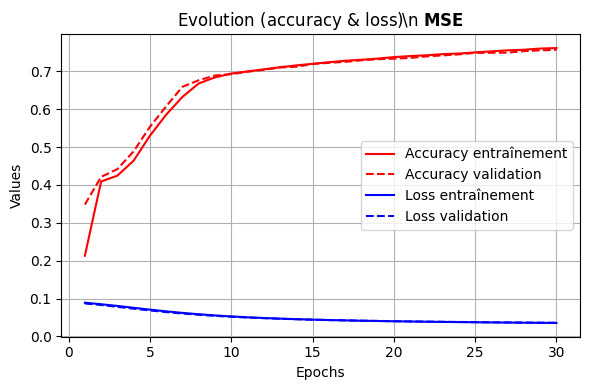

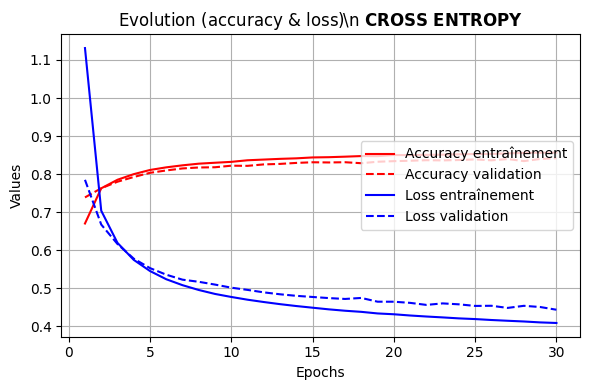

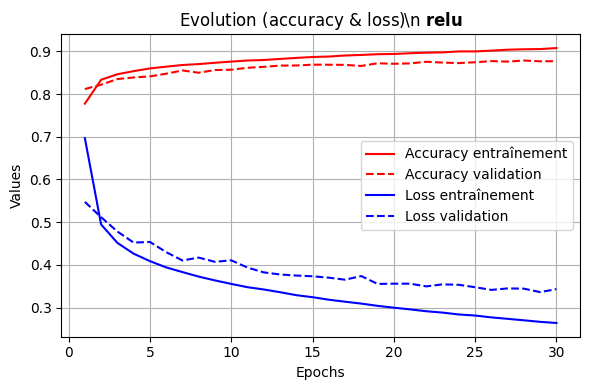

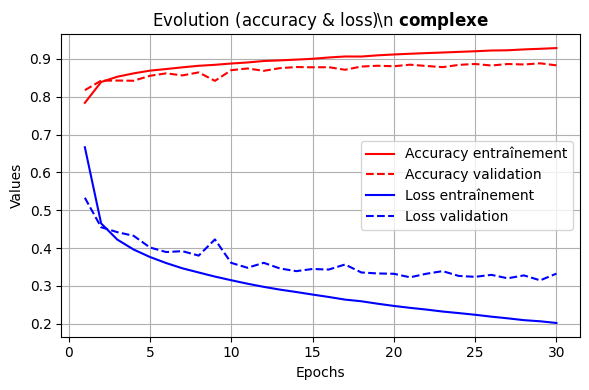

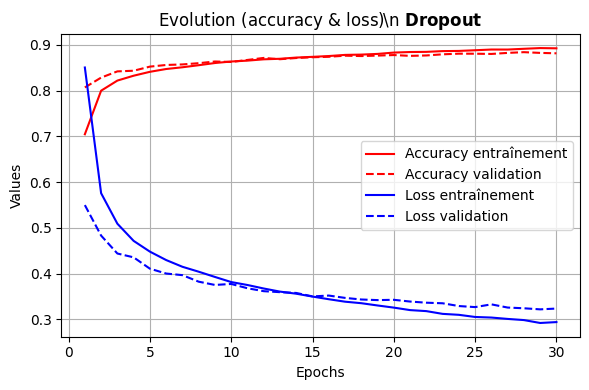

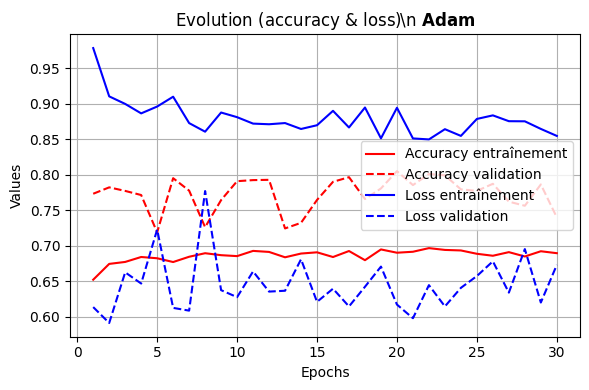

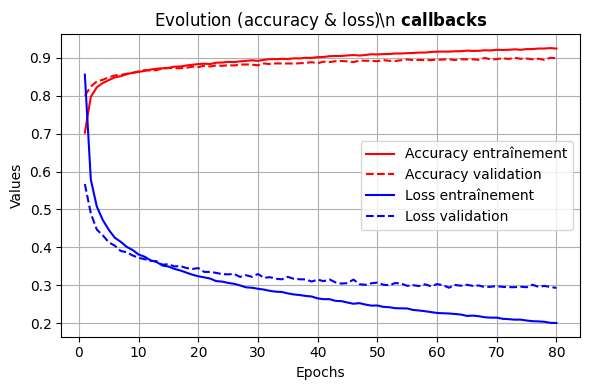

In [363]:
import matplotlib.pyplot as plt

def graph4val(history, name='ok'):

    # Récupération des métriques
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Création de la figure
    plt.figure(figsize=(6, 4))

    # Accuracy
    plt.plot(epochs, acc, 'r-', label='Accuracy entraînement')
    plt.plot(epochs, val_acc, 'r--', label='Accuracy validation')

    # Loss
    plt.plot(epochs, loss, 'b-', label='Loss entraînement')
    plt.plot(epochs, val_loss, 'b--', label='Loss validation')

    # Mise en forme
    name = name.replace(" ", r"\ ")
    plt.title(rf"Evolution (accuracy & loss)\n $\mathbf{{{name}}}$")
    plt.xlabel("Epochs")
    plt.ylabel("Values")
    plt.legend(loc="center right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



modes = ['MSE', 'CROSS ENTROPY', 'relu', 'complexe', 'Dropout', 'Adam','callbacks']
for mode in modes:
  graph4val(histos[mode], mode)

## Voici les 4 courbes clés pour suivre l’apprentissage du modèle : accuracy et loss sur entraînement et validation.

Visualisons clairement :

* Si le modèle progresse (accuracy monte, loss descendent),

* S’il généralise bien (val_accuracy proche de accuracy),

* Ou s’il sur-apprend (val_loss qui remonte alors que loss descend).

## 📊 Lecture des courbes

* Courbes rouges : accuracy (entraînement et validation)

* Courbes bleues : loss (entraînement et validation)

* Si les courbes de validation divergent de celles d’entraînement, c’est un signal d’overfitting.

* Si les 4 courbes convergent bien, le model est stable et performant.

In [364]:
import pandas as pd

# Initialiser une liste pour stocker les résultats
results = []

for mode in modes:
    h = histos[mode].history
    results.append({
        'Méthode': mode,
        'Accuracy': h['accuracy'][-1],
        'Val Accuracy': h['val_accuracy'][-1],
        'Loss': h['loss'][-1],
        'Val Loss': h['val_loss'][-1]
    })

# Créer le DataFrame
df = pd.DataFrame(results)
df

,Méthode,Accuracy,Val Accuracy,Loss,Val Loss
0,MSE,0.761367,0.7567,0.035382,0.035908
1,CROSS ENTROPY,0.856517,0.8417,0.409032,0.443820
2,relu,0.907550,0.8769,0.263988,0.343287
3,complexe,0.928383,0.8828,0.202153,0.332534
4,Dropout,0.892617,0.8817,0.294170,0.323740
5,Adam,0.689683,0.7400,0.854675,0.673221
6,callbacks,0.924667,0.8990,0.200461,0.293080


In [365]:
# Pour accuracy et val_accuracy → max
best_acc_idx = df['Accuracy'].idxmax()
best_val_acc_idx = df['Val Accuracy'].idxmax()

best_acc = df.loc[best_acc_idx, 'Méthode']
best_val_acc = df.loc[best_val_acc_idx, 'Méthode']

score_acc = df.loc[best_acc_idx, 'Accuracy']
score_val_acc = df.loc[best_val_acc_idx, 'Val Accuracy']

# Pour loss et val_loss → min
best_loss_idx = df['Loss'].idxmin()
best_val_loss_idx = df['Val Loss'].idxmin()

best_loss = df.loc[best_loss_idx, 'Méthode']
best_val_loss = df.loc[best_val_loss_idx, 'Méthode']

score_loss = df.loc[best_loss_idx, 'Loss']
score_val_loss = df.loc[best_val_loss_idx, 'Val Loss']

# Résumé sous forme de tableau
summary = pd.DataFrame({
    'Métrique': ['Accuracy', 'Val Accuracy', 'Loss', 'Val Loss'],
    'Meilleure Méthode': [best_acc, best_val_acc, best_loss, best_val_loss],
    'Meilleur Score': [score_acc, score_val_acc, score_loss, score_val_loss]
})

print(summary)

       Métrique Meilleure Méthode  Meilleur Score
0      Accuracy          complexe        0.928383
1  Val Accuracy         callbacks        0.899000
2          Loss               MSE        0.035382
3      Val Loss               MSE        0.035908


# Predictions

In [366]:
model_save = tf.keras.models.load_model('best_model.h5')

In [367]:
model_save.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [368]:
a_test_images[2500]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.02352941,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.18039216,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.19607843, 0.84705882, 1.        , 0.29411765, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.05490196, 0.74509804, 0.92156863, 0.79215686, 0.17254902,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.2627451 , 0.95686275, 0.92941176,
       0.91372549, 0.94901961, 0.92156863, 0.80392157, 0.71764706,
       0.57254902, 0.77254902, 0.88235294, 1.        , 0.95294

In [369]:
a_test_images[0].shape

(784,)

In [370]:
test_labels[2500]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [371]:
np.argmax(test_labels[2500])

np.int64(6)

In [372]:
labels[6]

'chemise'

In [373]:
pred = model_save.predict(a_test_images[2500].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


In [374]:
pred

array([[1.6947892e-03, 1.3454360e-05, 4.7532153e-01, 2.4259988e-04,
        2.6312569e-02, 1.4172605e-05, 4.9614570e-01, 2.9780579e-06,
        2.2943456e-04, 2.2732127e-05]], dtype=float32)

In [375]:
np.argmax(pred)

np.int64(6)

In [376]:
labels[2] # Bad predict

'pull'

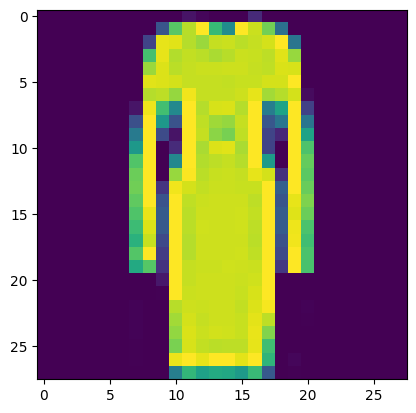

In [377]:
import matplotlib.pyplot as plt
plt.imshow(training_images[2500])
# plt.title(labels[training_labels[45]])
plt.show()

In [378]:
a_test_images[12].shape

(784,)

In [379]:
test_labels[12]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [380]:
labels[np.argmax(test_labels[12])]

'baskets'

In [381]:
pred = model_save.predict(a_test_images[7].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [382]:
pred

array([[4.6655754e-07, 8.3491783e-11, 1.5075772e-05, 4.0224492e-07,
        2.4155893e-03, 1.7399864e-09, 9.9756843e-01, 3.8039312e-13,
        2.1133427e-08, 2.5386607e-10]], dtype=float32)

In [383]:
np.argmax(pred)

np.int64(6)

In [384]:
labels[6] # Bad predict

'chemise'

In [385]:
a_test_images[0].shape

(784,)

In [386]:
test_labels[12]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [387]:
labels[np.argmax(test_labels[00])]

'bottines'

In [388]:
pred = model_save.predict(a_test_images[0].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [389]:
labels[np.argmax(pred)]

'bottines'

In [390]:
# (60000, 784) (1, 784)

In [391]:
a_test_images.shape

(10000, 784)

In [392]:
import random
import pandas as pd

# Select 12 random indices
random_indices = random.sample(range(a_test_images.shape[0]), 12)

# Get the corresponding images and labels
sample_images = a_test_images[random_indices]
sample_labels = test_labels[random_indices]

# Make predictions using the saved model
predictions = model_save.predict(sample_images)

# Get the predicted labels
predicted_labels = [labels[np.argmax(pred)] for pred in predictions]
true_labels = [labels[np.argmax(label)] for label in sample_labels]

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Image Index': random_indices,
    'True Label': true_labels,
    'Predicted Label': predicted_labels
})

# Add a column for correctness
results_df['Correct'] = ['✅' if true == pred else '❌' for true, pred in zip(true_labels, predicted_labels)]

display(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


,Image Index,True Label,Predicted Label,Correct
0,1069,t-shirt/haut,t-shirt/haut,✅
1,6630,sac,sac,✅
2,9264,sandales,sandales,✅
3,1891,sac,sac,✅
4,5858,baskets,baskets,✅
5,8721,robe,robe,✅
6,7804,baskets,baskets,✅
7,4292,robe,robe,✅
8,4201,pull,pull,✅
9,6695,sac,sac,✅


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


Image Index,Original Image,Predicted Label,Correct,Image Index,Original Image,Predicted Label,Correct,Image Index,Original Image,Predicted Label,Correct
1173,,pull,✅,7301,,pull,✅,234,,bottines,✅
6823,,bottines,✅,8118,,sac,✅,6550,,sandales,✅
2978,,t-shirt/haut,✅,9836,,baskets,✅,1399,,chemise,❌
2569,,manteau,✅,6213,,sac,✅,3658,,chemise,✅

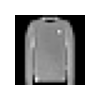
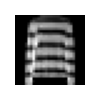
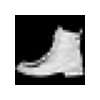
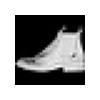
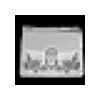
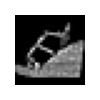
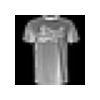
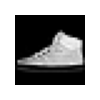
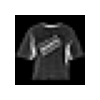
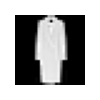
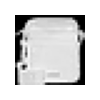
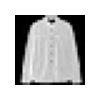

In [393]:
import random
import pandas as pd

# Select 12 random indices
random_indices = random.sample(range(a_test_images.shape[0]), 12)

# Get the corresponding images and labels
sample_images = a_test_images[random_indices]
sample_labels = test_labels[random_indices]

# Make predictions using the saved model
predictions = model_save.predict(sample_images)

# Get the predicted labels
predicted_labels = [labels[np.argmax(pred)] for pred in predictions]
true_labels = [labels[np.argmax(label)] for label in sample_labels]


import matplotlib.pyplot as plt
from IPython.display import display, HTML
import io
import base64

def display_image_table(indices, true_labels, predicted_labels, original_images):
    html = "<style> table, th, td { border: 1px solid black; text-align: center;}</style><table><tr>"
    # Add headers
    for _ in range(3):
        html += "<th>Image Index</th><th>Original Image</th><th>Predicted Label</th><th>Correct</th>"
    html += "</tr><tr>"

    for i, idx in enumerate(indices):
        correct = '✅' if true_labels[i] == predicted_labels[i] else '❌'
        # Create a plot for each image and save it as a PNG in memory
        fig, ax = plt.subplots(figsize=(1, 1))
        ax.imshow(original_images[idx], cmap='gray') # Display original image as requested
        ax.axis('off')
        plt.tight_layout()
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        plt.close(fig)
        img_base64 = base64.b64encode(buf.getvalue()).decode('utf-8')

        html += f"""
            <td>{idx}</td>
            <td><img src='data:image/png;base64,{img_base64}'/></td>
            <td>{predicted_labels[i]}</td>
            <td>{correct}</td>
        """
        # Start a new row after every 3 images
        if (i + 1) % 3 == 0:
            html += "</tr>"
            if i < len(indices) - 1:
                html += "<tr>"

    html += "</table>"
    display(HTML(html))

# Get the corresponding images and labels (using the previously generated random_indices)
sample_images_display = test_images[random_indices] # Use original images for display
sample_labels_display_text = [labels[np.argmax(label)] for label in test_labels[random_indices]]
predicted_labels_text = [labels[np.argmax(pred)] for pred in predictions]


display_image_table(random_indices, sample_labels_display_text, predicted_labels_text, test_images)

## Epoch 5/5

| Model         | Accuracy | Loss   | Val Accuracy | Val Loss |
|---------------|----------|--------|--------------|----------|
| MSE           | 0.5523   | 0.0708 | 0.5839       | 0.0674   |
| CROSS ENTROPY | 0.8085   | 0.5455 | 0.8037       | 0.5520   |
| relu          | 0.8570   | 0.4169 | 0.8406       | 0.4453   |
| model complexe| 0.8676   | 0.3768 | 0.8541       | 0.4082   |
| Dropout       | 0.8405   | 0.4501 | 0.8492       | 0.4157   |
| Adam          | 0.6805   | 0.8744 | 0.7445       | 0.6483   |
| Callbacks     | 0.8400   | 0.4521 | 0.8515       | 0.4164   |

## Epoch 50/50

| Model         | Accuracy | Loss   | Val Accuracy | Val Loss |
|---------------|----------|--------|--------------|----------|
| MSE           | 0.7930   | 0.0310 | 0.7834       | 0.0319   |
| CROSS ENTROPY | 0.8674   | 0.3769 | 0.8482       | 0.4202   |
| relu          | 0.9247   | 0.2136 | 0.8892       | 0.3137   |
| model complexe| 0.9536   | 0.1322 | 0.8966       | 0.3154   |
| Dropout       | 0.9107   | 0.2454 | 0.8954       | 0.3021   |
| Adam          | 0.6543   | 0.9675 | 0.7221       | 0.7787   |
| Callbacks     | 0.8815   | 0.3273 | 0.8764       | 0.3416   |

(Callbacks s'est arrêté à 20/50)